# 강원도 산불-공간 데이터 심화 시각화 분석 (Visualization-centric Spatial EDA)

## 1. 분석 목적 및 개요
- 본 분석은 강원도 지역에서 발생한 산불 데이터를 대상으로 **날씨 변수를 통제한 상태에서 순수 공간적·지형적 취약성 요인(Spatial/Topographic Risk Factors)**을 다차원 시각화를 중심으로 정밀 분석한다.
- **인간 활동과의 연관성 규명**: 산불 발생 주소명(`발생지역번지`)에 '산'이 포함되는지 여부에 따라 **임야번지(산)** 집단과 **일반번지** 집단으로 대칭 분할하여 비교 분석을 수행한다.
- **다각도 고급 시각화**: 
  1. **지리지형 공간 맵핑**: 강원도 기상 격자 구역을 배경 지도로 활용하여 산불 포인트의 지리적 밀집도와 핫스팟 영역(KDE Contour)을 오버레이 시각화한다.
  2. **상세 토지피복 매핑**: 대분류(L1) 분포뿐 아니라 산불이 유발되는 상위 10개 중분류(L2) 토지피복(침엽수림, 도로, 주거지 등)의 구성비 차이를 비교한다.
  3. **5대 인프라 접근성 분석**: 등산로, 임도, 도로, 소방서, 소방용수시설까지의 최단 거리 분포를 Boxplot 및 ECDF(누적분포함수) 통합 플롯으로 시각화한다.
  4. **4대 지형 환경 특성 분석**: 고도, 경사도, TPI(지형위치지수), TWI(지형다습지수)의 확률밀도함수(KDE) 및 ECDF를 시각화하여 산불의 환경적 취약성을 파악한다.
  5. **사면(Aspect) 극좌표 장미 도표**: 삼각함수로 변환되었던 사면 방향을 실제 방위각(0~360도)으로 복원하여, 임야 vs 일반 집단의 방위별 발생 빈도를 극좌표 히스토그램으로 비교한다.
  6. **상관관계 히트맵**: 지형 및 인프라 접근성 변수들 간의 상호 작용 메커니즘이 두 그룹에서 어떻게 다른지 Spearman 상관관계 분석을 시각화한다.
- **통계 검정 결합**: 모든 시각화 단계마다 비모수 검정인 **Mann-Whitney U 검정** 및 **Cohen's d 효과크기** 검증을 연계하여 시각적 차이의 과학적 정당성을 확보한다.
- 본 분석을 통하여 향후 기상 복합 지수(WFRI) 모델과 결합하여 송배전 설비 주변의 화재 취약성 등급 지도를 도출하기 위한 공간적 가중치 설계 근거를 제공한다.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree
from pathlib import Path
import time

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    def Markdown(text):
        return text

# 한글 폰트 설정 (맑은 고딕)
font_path = 'C:/Windows/Fonts/malgun.ttf'
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = 'DejaVu Sans'

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
    },
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

ROOT = Path('D:/farm-system-public-02')
FIRE_DIR = ROOT / 'data' / '강원도_데이터'
SPATIAL_DIR = FIRE_DIR / '강원도_공간데이터'
FIRE_SPATIAL_DIR = FIRE_DIR / '산불_공간데이터'

print('ROOT Directory:', ROOT)
print('Matplotlib 한글 폰트 설정 완료:', plt.rcParams['font.family'])


ROOT Directory: D:\farm-system-public-02
Matplotlib 한글 폰트 설정 완료: ['Malgun Gothic']


## 2. 데이터 로드 및 이상치 정제
- 산불 발생 위치 데이터와 다양한 지리 공간 및 지형 레이어 데이터를 로드하고, 좌표계를 평면 투영 좌표계인 **`EPSG:5186` (Korea 2000 / East Belt)**로 일치시켜 미터(m) 단위의 정확한 거리 연산 기반을 다진다.
- 지형 데이터 중 지형다습지수(TWI) 컬럼 내에 결측 대체 극단치로 채워진 값($1.6 	imes 10^9$ 이상)들을 탐지하여 분석 왜곡 방지를 위해 `NaN`으로 정제한다.


In [2]:
t0 = time.time()

# 1. 산불 데이터 로드 및 geometry 변환
print('1) 강원도 산불 발생 데이터 로드...')
fire_df = pd.read_csv(FIRE_DIR / '강원도_산불발생.csv', encoding='utf-8')
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df['경도'], fire_df['위도']),
    crs='EPSG:4326'
).to_crs('EPSG:5186')

# 2. 번지명에 '산'이 포함되는지 여부로 이분화 변수 생성
fire_gdf['is_mountain_address'] = fire_gdf['발생지역번지'].astype(str).str.contains('산')
fire_gdf['addr_type'] = fire_gdf['is_mountain_address'].map({True: '임야번지(산)', False: '일반번지'})

# 3. 선형 인프라 데이터 로드
print('2) 등산로 및 임도 데이터 로드...')
trail_df = pd.read_csv(SPATIAL_DIR / '강원도_등산로.csv', encoding='utf-8')
trail_df['geometry'] = trail_df['공간좌표'].apply(wkt.loads)
trail_gdf = gpd.GeoDataFrame(trail_df, geometry='geometry', crs='EPSG:4326').to_crs('EPSG:5186')

imdo_df = pd.read_csv(SPATIAL_DIR / '강원도_임도망도.csv', encoding='utf-8')
imdo_df['geometry'] = imdo_df['공간좌표'].apply(wkt.loads)
imdo_gdf = gpd.GeoDataFrame(imdo_df, geometry='geometry', crs='EPSG:4326').to_crs('EPSG:5186')

# 4. 소방 인프라 데이터 로드
print('3) 소방서 및 소방용수시설 데이터 로드...')
fs_df = pd.read_csv(FIRE_SPATIAL_DIR / '강원도_근방_소방서_위치.csv', encoding='utf-8')
fs_gdf = gpd.GeoDataFrame(
    fs_df,
    geometry=gpd.points_from_xy(fs_df['경도'], fs_df['위도']),
    crs='EPSG:4326'
).to_crs('EPSG:5186')

fw_df = pd.read_csv(FIRE_SPATIAL_DIR / '강원도_근방_소방용수시설_위치.csv', encoding='utf-8')
fw_gdf = gpd.GeoDataFrame(
    fw_df,
    geometry=gpd.points_from_xy(fw_df['경도'], fw_df['위도']),
    crs='EPSG:4326'
).to_crs('EPSG:5186')

# 5. 도로 및 토지피복 GPKG 파일 로드 (pyogrio 고속 엔진)
print('4) 토지피복 및 도로 GPKG 레이어 로드...')
land_gdf = gpd.read_file(SPATIAL_DIR / '강원도_토지피복도_세분류_병합_1m.gpkg', engine='pyogrio')
road_gdf = gpd.read_file(SPATIAL_DIR / '강원도_병합_도로.gpkg', engine='pyogrio')

land_gdf = land_gdf.to_crs(fire_gdf.crs)
road_gdf = road_gdf.to_crs(fire_gdf.crs)

# 6. 산불 발생 지점의 지형 특성 데이터 병합 및 TWI 이상치 정제
print('5) 지형 특성 데이터 로드 및 TWI 이상치 정제...')
topo_df = pd.read_csv(FIRE_SPATIAL_DIR / '강원도_산불_지형특성계산.csv', encoding='utf-8')
fire_gdf = fire_gdf.merge(
    topo_df[['fire_id', '고도(m)', '경사도(도)', '사면방향_sin', '사면방향_cos', 'TPI(지형위치지수)', 'TWI(지형다습지수)']],
    on='fire_id',
    how='left'
)

# TWI 컬럼 이상치(결측 처리용 1e9 이상 극단치) 제거
twi_outliers = (fire_gdf['TWI(지형다습지수)'] > 1e8).sum()
fire_gdf.loc[fire_gdf['TWI(지형다습지수)'] > 1e8, 'TWI(지형다습지수)'] = np.nan

t1 = time.time()
print(f'\n>>> 데이터 로드 및 이상치 정제 완료 (소요시간: {t1-t0:.2f}초)')
print(f'- 로드된 산불 데이터 크기: {fire_gdf.shape}')
print(f'- TWI 극단값 정제 건수: {twi_outliers}건')
print(f'- 번지 구분별 산불 건수:\n{fire_gdf["addr_type"].value_counts()}')


1) 강원도 산불 발생 데이터 로드...
2) 등산로 및 임도 데이터 로드...


3) 소방서 및 소방용수시설 데이터 로드...
4) 토지피복 및 도로 GPKG 레이어 로드...


5) 지형 특성 데이터 로드 및 TWI 이상치 정제...

>>> 데이터 로드 및 이상치 정제 완료 (소요시간: 38.30초)
- 로드된 산불 데이터 크기: (3405, 25)
- TWI 극단값 정제 건수: 480건
- 번지 구분별 산불 건수:
addr_type
일반번지       2618
임야번지(산)     787
Name: count, dtype: int64


## 3. 지리 공간 분포 지도 및 밀도 분석 (Spatial Mapping & KDE)
- 강원도 날씨 격자 데이터 경계(`강원도날씨_격자.geojson`)를 로드하여 지도 배경 레이어로 사용한다.
- **공간 산점도 지도**: 임야번지 산불과 일반번지 산불의 지리적 발생 포인트를 중첩(Overlay)하여 고도축과 배후 지역 간의 대략적인 분포 차이를 시각화한다.
- **공간 밀도 지도 (2D KDE Contour)**: 경도와 위도를 평면 축으로 하여 공간 밀도 분포 커널밀도추정(KDE)을 집단별로 오버레이함으로써, 산불 유형에 따른 강원도 내 공간적 발생 핫스팟의 지리적 차이를 명확하게 비교한다.


강원도 기상 격자 지도 로딩...


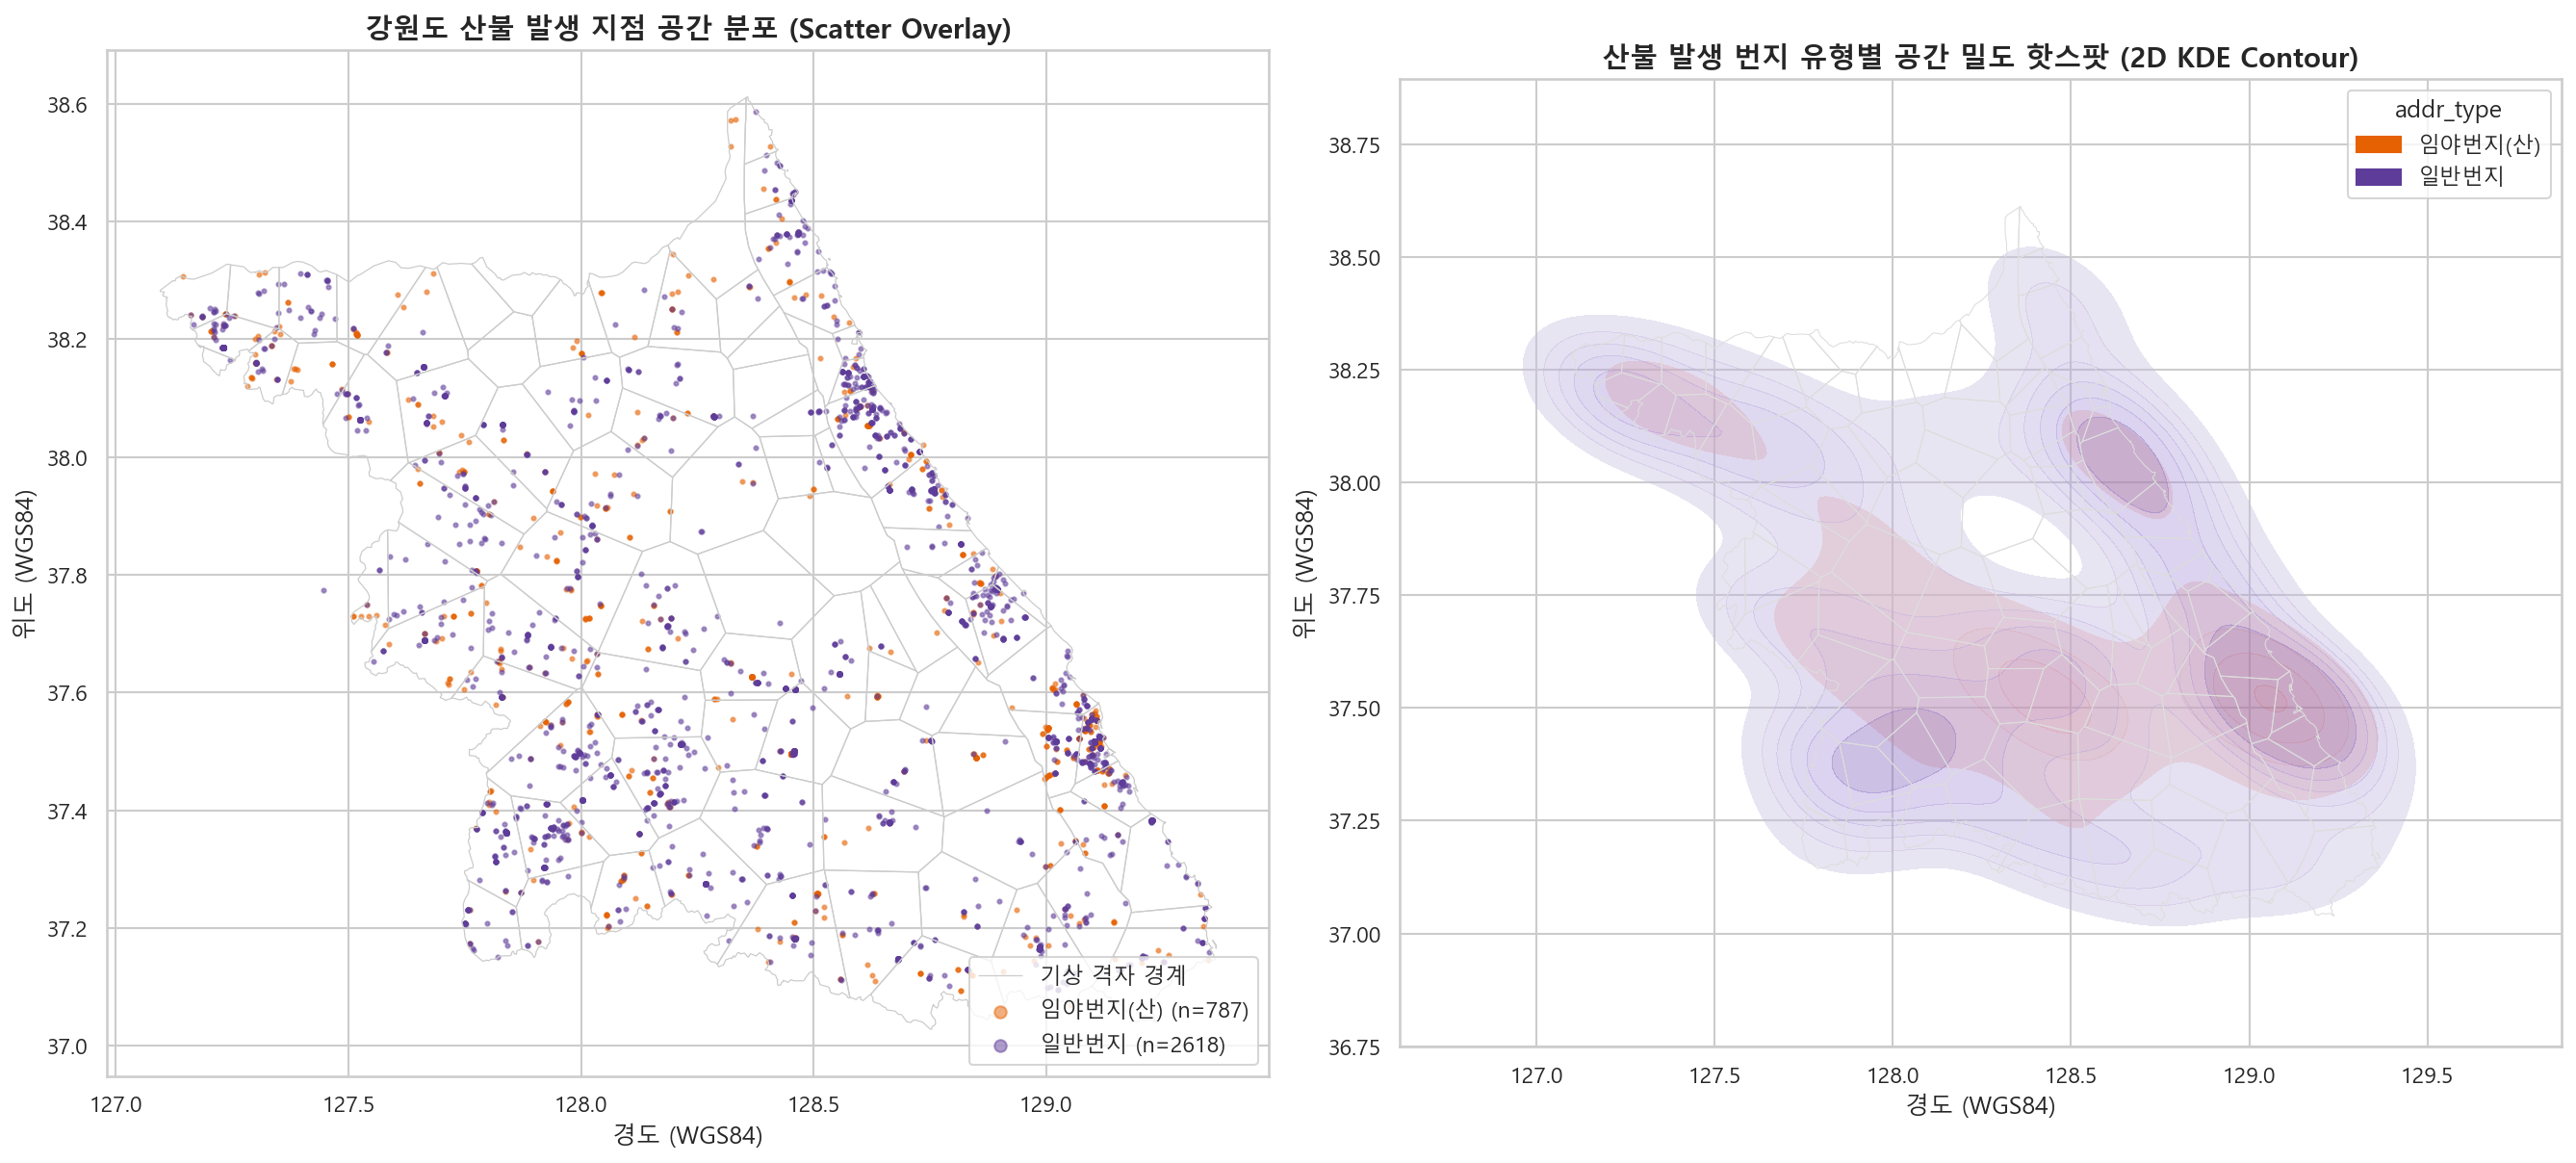

In [3]:
print('강원도 기상 격자 지도 로딩...')
grid_gdf = gpd.read_file(ROOT / 'data' / '강원도_날씨데이터' / '강원도날씨_격자.geojson').to_crs('EPSG:4326')

palette = {'임야번지(산)': '#E66101', '일반번지': '#5E3C99'}
order = ['임야번지(산)', '일반번지']

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=150)

# 1. 공간 분포 산점도 지도
grid_gdf.boundary.plot(ax=axes[0], color='#CCCCCC', linewidth=0.6, label='기상 격자 경계')
for addr, color in palette.items():
    subset = fire_gdf[fire_gdf['addr_type'] == addr]
    axes[0].scatter(
        subset['경도'], subset['위도'], 
        color=color, alpha=0.5, s=4, label=f'{addr} (n={len(subset)})'
)
axes[0].set_title('강원도 산불 발생 지점 공간 분포 (Scatter Overlay)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('경도 (WGS84)')
axes[0].set_ylabel('위도 (WGS84)')
axes[0].legend(loc='lower right', markerscale=3, frameon=True)

# 2. 공간 밀도 지도 (2D KDE)
grid_gdf.boundary.plot(ax=axes[1], color='#DDDDDD', linewidth=0.5)
sns.kdeplot(
    data=fire_gdf,
    x='경도', y='위도',
    hue='addr_type',
    hue_order=order,
    palette=palette,
    alpha=0.4,
    levels=7,
    fill=True,
    thresh=0.15,
    ax=axes[1]
)
axes[1].set_title('산불 발생 번지 유형별 공간 밀도 핫스팟 (2D KDE Contour)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('경도 (WGS84)')
axes[1].set_ylabel('위도 (WGS84)')

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_gis_overlay.png', dpi=300)
plt.show()


## 4. 토지 피복도 공간 조인 및 분포 시각화
- `gpd.sjoin`을 활용하여 산불 발생 지점의 환경부 토지피복 데이터를 공간 결합(Point-in-Polygon)한다.
- 경계 오차 등으로 여러 폴리곤에 중첩 매칭되는 건들을 중복 제거(`drop_duplicates`)하여 데이터 신뢰도를 높인다.
- **토지피복 대분류(L1) 점유비율**: 두 그룹의 산불이 어떤 환경(산림, 초지, 주거지, 도로 등)에서 주로 촉발되었는지 전체 스택 바차트로 비교한다.
- **상위 10대 토지피복 중분류(L2) 비교**: 더 구체적으로 침엽수림, 활엽수림, 도로, 밭, 논 등 10개 피복에 대해 두 집단 간 빈도와 점유 비율의 차이를 그룹형 수평 바차트(Grouped Horizontal Barplot)로 시각화한다.


산불 발생 지점과 토지피복 공간 조인 진행 중...


공간 조인 및 정제 완료 (소요시간: 1.89초)


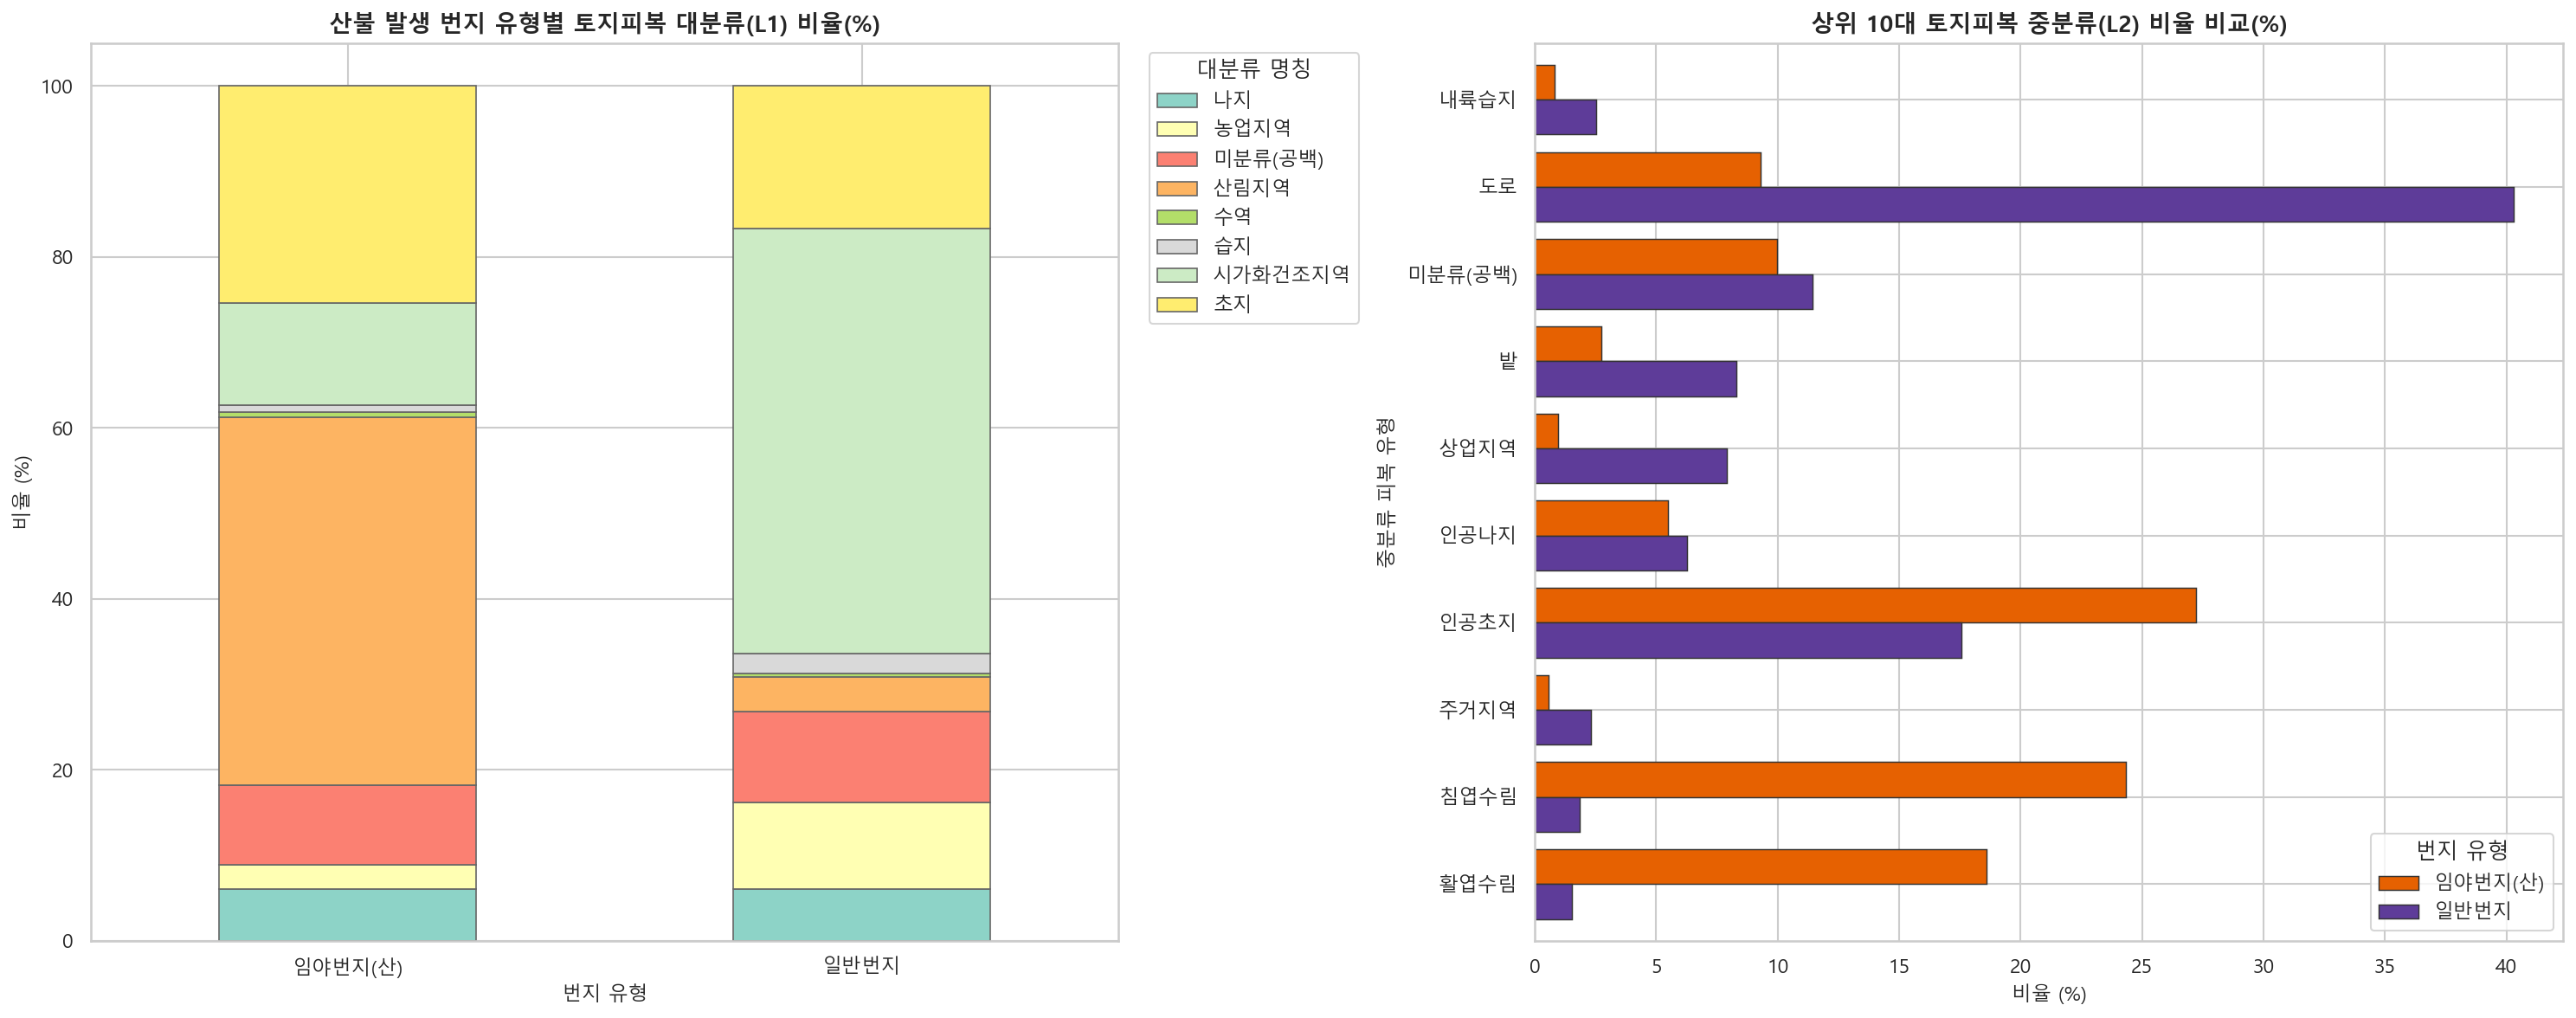

In [4]:
t0 = time.time()
print('산불 발생 지점과 토지피복 공간 조인 진행 중...')

fire_land = gpd.sjoin(
    fire_gdf,
    land_gdf[['L1_NAME', 'L2_NAME', 'geometry']],
    how='left',
    predicate='within'
).drop(columns=['index_right'])

# 중복 매칭 처리 및 인덱스 정제
fire_land = fire_land.drop_duplicates(subset='fire_id', keep='first').reset_index(drop=True)
fire_land['L1_NAME'] = fire_land['L1_NAME'].fillna('미분류(공백)')
fire_land['L2_NAME'] = fire_land['L2_NAME'].fillna('미분류(공백)')

t1 = time.time()
print(f'공간 조인 및 정제 완료 (소요시간: {t1-t0:.2f}초)')

# 시각화 작성
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

# 1. L1 대분류 점유 비율 Stacked Bar
l1_ct = pd.crosstab(fire_land['L1_NAME'], fire_land['addr_type'], normalize='columns') * 100
l1_ct = l1_ct.reindex(columns=order)
l1_ct.T.plot(kind='bar', stacked=True, colormap='Set3', edgecolor='#666666', linewidth=0.8, ax=axes[0])
axes[0].set_title('산불 발생 번지 유형별 토지피복 대분류(L1) 비율(%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('번지 유형', fontsize=11)
axes[0].set_ylabel('비율 (%)', fontsize=11)
axes[0].set_xticklabels(order, rotation=0)
axes[0].legend(title='대분류 명칭', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# 2. 상위 10개 L2 중분류 점유 비율 Grouped Bar
top_l2 = fire_land['L2_NAME'].value_counts().head(10).index
l2_df = fire_land[fire_land['L2_NAME'].isin(top_l2)]
l2_ct = pd.crosstab(l2_df['L2_NAME'], l2_df['addr_type'], normalize='columns') * 100
l2_ct = l2_ct.reindex(columns=order)

l2_ct.plot(kind='barh', figsize=None, width=0.8, color=['#E66101', '#5E3C99'], edgecolor='#333333', linewidth=0.7, ax=axes[1])
axes[1].set_title('상위 10대 토지피복 중분류(L2) 비율 비교(%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('비율 (%)', fontsize=11)
axes[1].set_ylabel('중분류 피복 유형', fontsize=11)
axes[1].legend(title='번지 유형', loc='lower right', frameon=True)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_landcover_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. STRtree 공간인덱스를 활용한 5대 인프라 최단거리 계산
- 대량의 GIS 선형/점형 기하 데이터 사이의 최단을 고속으로 구하기 위해 `shapely.strtree.STRtree` (2D R-tree 인덱스)를 구축한다.
- **분석 인프라**: 등산로, 임도, 도로, 소방서, 소방용수시설까지의 최단 거리(m)를 각각 연산한다.


In [5]:
def calculate_nearest_distance(points_gdf, target_gdf):
    target_geoms = target_gdf['geometry'].dropna().values
    tree = STRtree(target_geoms)
    # 최인접 geometry 인덱스 찾기
    nearest_indices = tree.nearest(points_gdf['geometry'].values)
    
    distances = []
    for idx, pt in enumerate(points_gdf['geometry'].values):
        nearest_geom = target_geoms[nearest_indices[idx]]
        distances.append(pt.distance(nearest_geom))
    return distances

t0 = time.time()
print('1) 등산로 최단 거리 계산...')
fire_land['등산로_최단거리_m'] = calculate_nearest_distance(fire_land, trail_gdf)

print('2) 임도 최단 거리 계산...')
fire_land['임도_최단거리_m'] = calculate_nearest_distance(fire_land, imdo_gdf)

print('3) 도로 최단 거리 계산...')
fire_land['도로_최단거리_m'] = calculate_nearest_distance(fire_land, road_gdf)

print('4) 소방서 최단 거리 계산...')
fire_land['소방서_최단거리_m'] = calculate_nearest_distance(fire_land, fs_gdf)

print('5) 소방용수시설 최단 거리 계산...')
fire_land['소방용수_최단거리_m'] = calculate_nearest_distance(fire_land, fw_gdf)

t1 = time.time()
print(f'\n>>> 5대 인프라 최단 거리 연산 완료 (소요시간: {t1-t0:.2f}초)')
display(fire_land[[
    '등산로_최단거리_m', '임도_최단거리_m', '도로_최단거리_m', '소방서_최단거리_m', '소방용수_최단거리_m'
]].describe())


1) 등산로 최단 거리 계산...


2) 임도 최단 거리 계산...


3) 도로 최단 거리 계산...


4) 소방서 최단 거리 계산...
5) 소방용수시설 최단 거리 계산...

>>> 5대 인프라 최단 거리 연산 완료 (소요시간: 2.02초)


,등산로_최단거리_m,임도_최단거리_m,도로_최단거리_m,소방서_최단거리_m,소방용수_최단거리_m
count,3405.000000,3405.000000,3405.000000,3405.000000,3405.000000
mean,1869.513915,4663.701107,33.856684,5283.157269,932.529899
std,2078.077482,3305.457270,197.248217,4625.554084,1485.144191
min,0.073597,0.424022,0.000000,37.239756,4.302673
25%,446.120649,2427.917634,0.000000,1606.897260,124.741740
50%,1111.297132,3709.562275,3.218760,3980.522185,294.051733
75%,2564.040478,6256.200601,15.790793,8114.096153,1057.874034
max,16883.667164,27048.663273,4869.985914,24175.272924,11070.784173


## 6. 5대 인프라 최단거리 분포 시각화 및 비모수 가설검정
- **인프라 거리 비교 차트**: 5개 접근성 변수 전체에 대해 **`5 x 2` Subplot** 레이아웃을 생성한다.
  - **좌측 (Boxplot)**: 임야 vs 일반 집단 간의 거리를 상자그림으로 표현하되, 극단 아웃라이어 가독성을 위해 로그 스케일(Log Scale)을 취한다.
  - **우측 (ECDF)**: 누적분포함수(ECDF) 곡선을 그려 집단 간 거동이 갈라지는 지점을 정밀 분석한다.
- **통계 검정**: 정규성을 만족하지 않는 거리 특성을 고려해 **Mann-Whitney U 비모수 검정**을 수행하고, 효과크기인 **Cohen's d**를 통해 두 그룹 차이의 강도를 요약한다.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


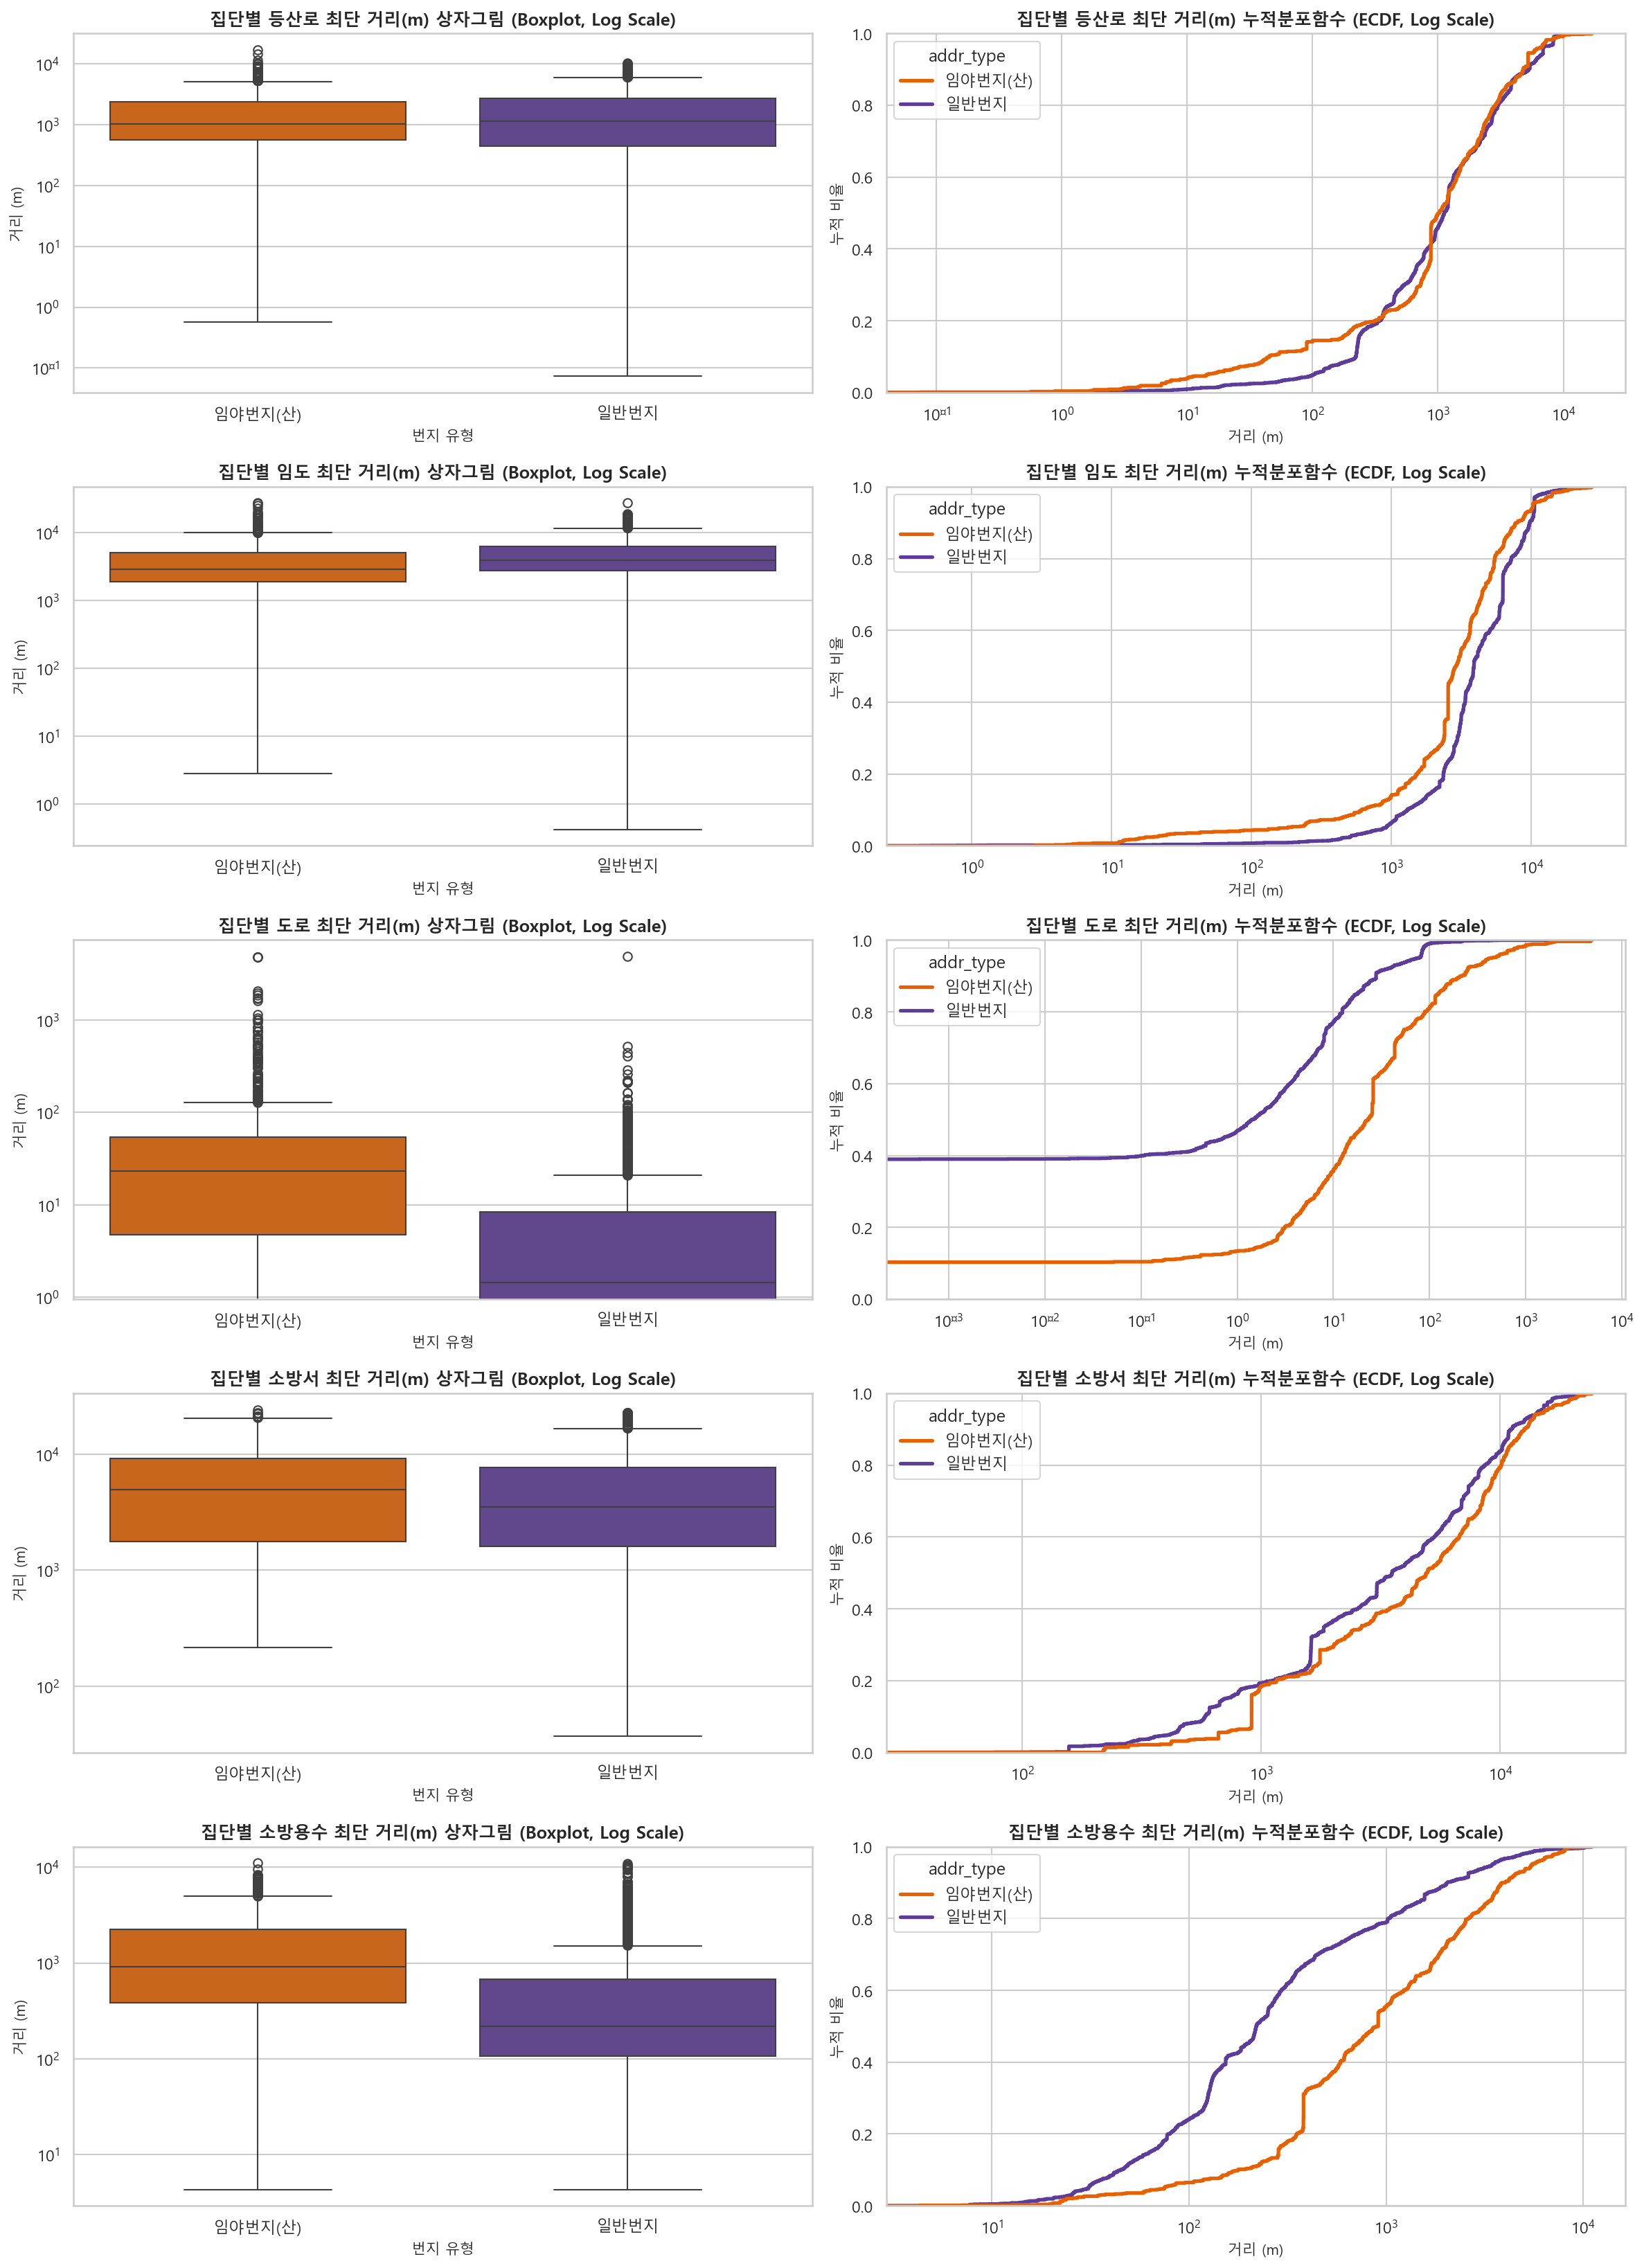

### 5대 인프라 거리 가설검정 및 효과크기 요약

,변수명,임야_중앙값(m),일반_중앙값(m),p-value,효과크기 (Cohen's d)
0,등산로 최단 거리(m),1020.482215,1123.130083,3.567292e-01,-0.039518
1,임도 최단 거리(m),2885.505028,3880.692538,1.418380e-22,-0.292587
2,도로 최단 거리(m),23.136625,1.434922,1.002591e-118,0.466473
3,소방서 최단 거리(m),4919.112172,3525.801626,2.616986e-07,0.205257
4,소방용수 최단 거리(m),911.054815,219.614333,1.823723e-91,0.596314


In [6]:
dist_vars = {
    '등산로_최단거리_m': '등산로 최단 거리(m)',
    '임도_최단거리_m': '임도 최단 거리(m)',
    '도로_최단거리_m': '도로 최단 거리(m)',
    '소방서_최단거리_m': '소방서 최단 거리(m)',
    '소방용수_최단거리_m': '소방용수 최단 거리(m)'
}

fig, axes = plt.subplots(5, 2, figsize=(16, 22), dpi=150)

dist_stats = []
group_m = fire_land[fire_land['is_mountain_address'] == True]
group_g = fire_land[fire_land['is_mountain_address'] == False]

for idx, (col, label) in enumerate(dist_vars.items()):
    # 1. Boxplot (Log Scale)
    sns.boxplot(
        data=fire_land,
        x='addr_type',
        y=col,
        order=order,
        palette=palette,
        ax=axes[idx, 0]
    )
    axes[idx, 0].set_yscale('log')
    axes[idx, 0].set_title(f'집단별 {label} 상자그림 (Boxplot, Log Scale)', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('번지 유형', fontsize=10)
    axes[idx, 0].set_ylabel('거리 (m)', fontsize=10)
    
    # 2. ECDF (Log Scale)
    sns.ecdfplot(
        data=fire_land,
        x=col,
        hue='addr_type',
        hue_order=order,
        palette=palette,
        lw=2.5,
        ax=axes[idx, 1]
    )
    axes[idx, 1].set_xscale('log')
    axes[idx, 1].set_title(f'집단별 {label} 누적분포함수 (ECDF, Log Scale)', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('거리 (m)', fontsize=10)
    axes[idx, 1].set_ylabel('누적 비율', fontsize=10)
    
    # 가설검정 및 효과크기 계산
    m_vals = group_m[col].dropna().values
    g_vals = group_g[col].dropna().values
    
    u_stat, p_val = stats.mannwhitneyu(m_vals, g_vals, alternative='two-sided')
    pooled_std = np.sqrt(((len(m_vals) - 1) * np.var(m_vals, ddof=1) + (len(g_vals) - 1) * np.var(g_vals, ddof=1)) / (len(m_vals) + len(g_vals) - 2))
    d_val = (np.mean(m_vals) - np.mean(g_vals)) / pooled_std if pooled_std > 0 else 0.0
    
    dist_stats.append({
        '변수': col,
        '변수명': label,
        '임야_중앙값(m)': np.median(m_vals),
        '일반_중앙값(m)': np.median(g_vals),
        'U 통계량': u_stat,
        'p-value': p_val,
        '효과크기 (Cohen\'s d)': d_val
    })

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_distances.png', dpi=300)
plt.show()

# 검정 요약 테이블 출력
dist_stats_df = pd.DataFrame(dist_stats)
display(Markdown('### 5대 인프라 거리 가설검정 및 효과크기 요약'))
display(dist_stats_df[['변수명', '임야_중앙값(m)', '일반_중앙값(m)', 'p-value', '효과크기 (Cohen\'s d)']])


## 7. 4대 지형 환경 요인 분포 시각화 및 비모수 가설검정
- **지형 요인 비교 차트**: 고도, 경사도, TPI, TWI 4가지 지형 인자에 대해 **`4 x 2` Subplot** 레이아웃을 생성한다.
  - **좌측 (KDE)**: 연속적인 분포의 형태를 뚜렷하게 겹쳐서 확인하기 위해 확률밀도함수(KDE Plot)를 시각화한다.
  - **우측 (ECDF)**: 지형 특성에 따른 두 집단의 고저/경사 분포 격차 추세를 누적으로 확인한다.
- 이상치 정제가 적용된 TWI 지수와 산지 축 결정을 위한 고도/경사의 유의적 효과 크기를 정밀 측정한다.


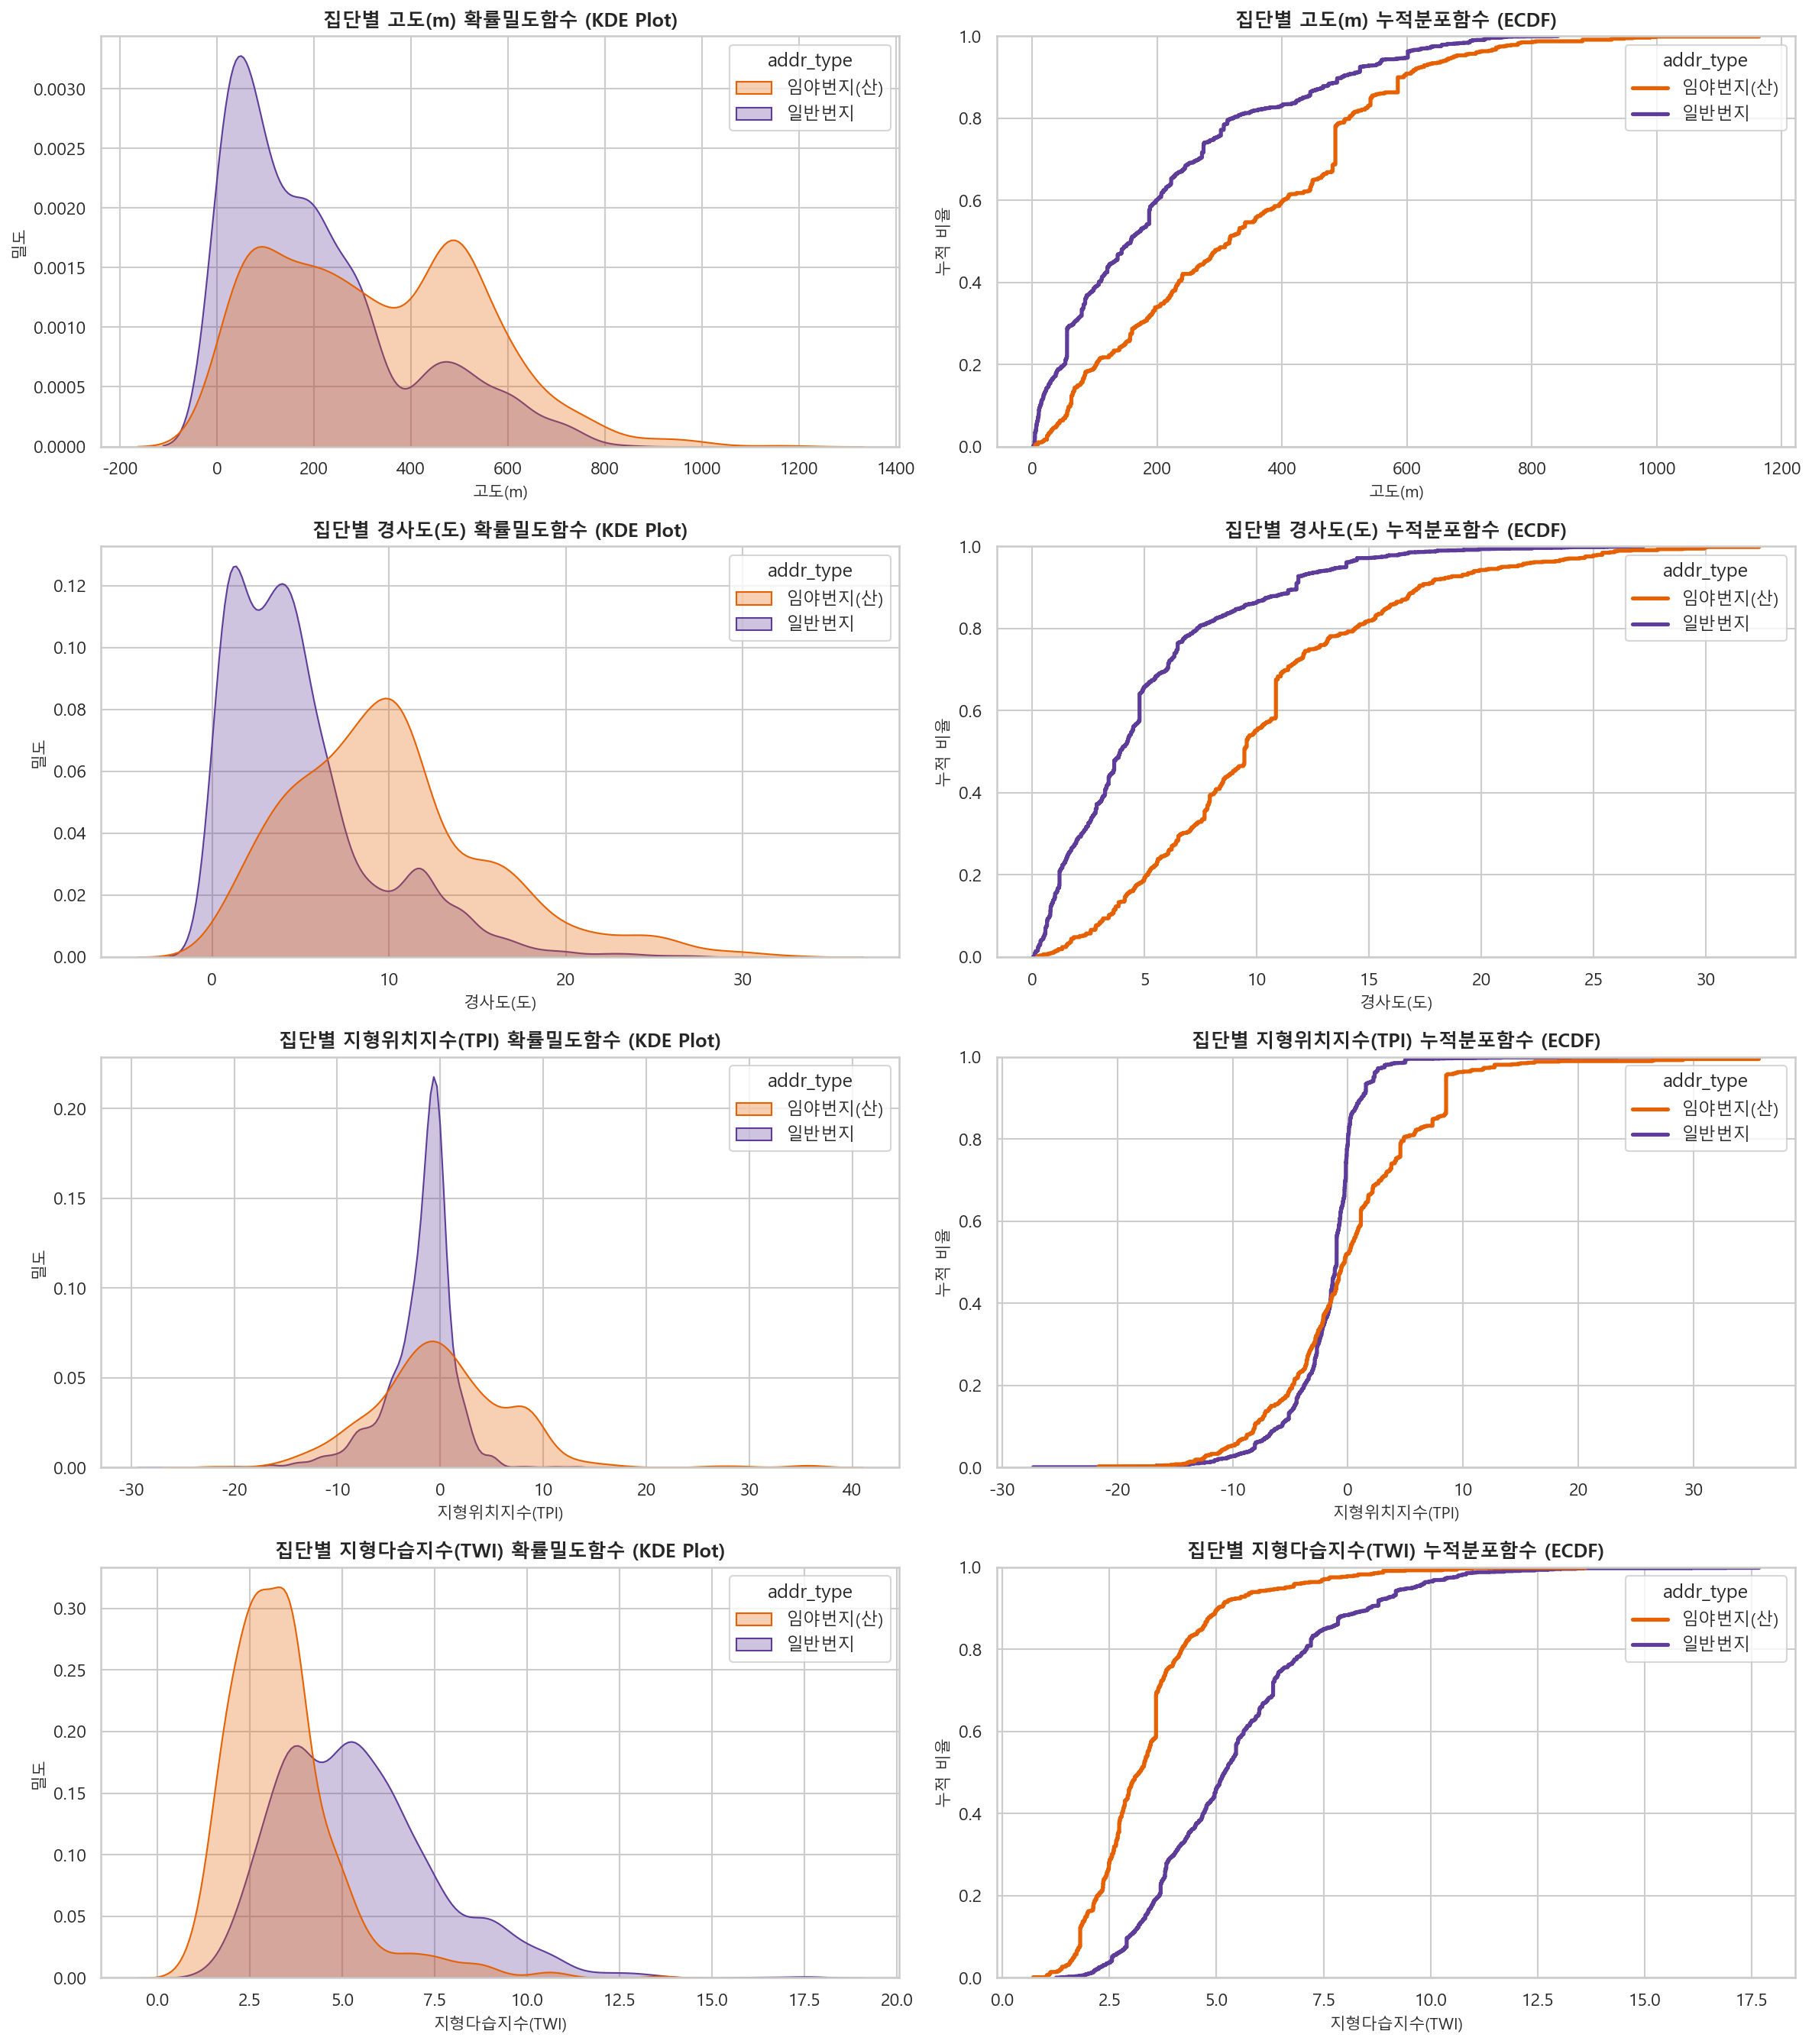

### 4대 지형 요인 가설검정 및 효과크기 요약

,변수명,임야_중앙값,일반_중앙값,p-value,효과크기 (Cohen's d)
0,고도(m),315.546630,157.424160,2.741338e-53,0.668266
1,경사도(도),9.454021,3.930461,6.003972e-128,1.107490
2,지형위치지수(TPI),-0.281410,-0.978512,5.193851e-15,0.445609
3,지형다습지수(TWI),3.190719,5.190454,1.090027e-128,-1.016169


In [7]:
topo_vars = {
    '고도(m)': '고도(m)',
    '경사도(도)': '경사도(도)',
    'TPI(지형위치지수)': '지형위치지수(TPI)',
    'TWI(지형다습지수)': '지형다습지수(TWI)'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18), dpi=150)

topo_stats = []

for idx, (col, label) in enumerate(topo_vars.items()):
    # 1. KDE plot
    sns.kdeplot(
        data=fire_land,
        x=col,
        hue='addr_type',
        hue_order=order,
        palette=palette,
        fill=True,
        alpha=0.3,
        common_norm=False,
        ax=axes[idx, 0]
    )
    axes[idx, 0].set_title(f'집단별 {label} 확률밀도함수 (KDE Plot)', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(label, fontsize=10)
    axes[idx, 0].set_ylabel('밀도', fontsize=10)
    
    # 2. ECDF
    sns.ecdfplot(
        data=fire_land,
        x=col,
        hue='addr_type',
        hue_order=order,
        palette=palette,
        lw=2.5,
        ax=axes[idx, 1]
    )
    axes[idx, 1].set_title(f'집단별 {label} 누적분포함수 (ECDF)', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(label, fontsize=10)
    axes[idx, 1].set_ylabel('누적 비율', fontsize=10)
    
    # 가설검정 및 효과크기 계산
    m_vals = group_m[col].dropna().values
    g_vals = group_g[col].dropna().values
    
    u_stat, p_val = stats.mannwhitneyu(m_vals, g_vals, alternative='two-sided')
    pooled_std = np.sqrt(((len(m_vals) - 1) * np.var(m_vals, ddof=1) + (len(g_vals) - 1) * np.var(g_vals, ddof=1)) / (len(m_vals) + len(g_vals) - 2))
    d_val = (np.mean(m_vals) - np.mean(g_vals)) / pooled_std if pooled_std > 0 else 0.0
    
    topo_stats.append({
        '변수': col,
        '변수명': label,
        '임야_중앙값': np.median(m_vals),
        '일반_중앙값': np.median(g_vals),
        'U 통계량': u_stat,
        'p-value': p_val,
        '효과크기 (Cohen\'s d)': d_val
    })

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_topo.png', dpi=300)
plt.show()

# 검정 요약 테이블 출력
topo_stats_df = pd.DataFrame(topo_stats)
display(Markdown('### 4대 지형 요인 가설검정 및 효과크기 요약'))
display(topo_stats_df[['변수명', '임야_중앙값', '일반_중앙값', 'p-value', '효과크기 (Cohen\'s d)']])


## 8. 사면 방향(Aspect) 극좌표 분석
- 사면방향_sin(동서) 및 cos(남북) 변수로부터 삼각함수 역산(`np.arctan2`)을 통해 실제 사면의 방위각(0~360도)을 도출한다.
- **극좌표 장미 도표 (Polar Aspect Rose Diagram)**: 임야번지와 일반번지 산불 발생지의 사면 방향 분포를 1행 2열의 극좌표 원형 히스토그램으로 시각화한다. 이를 통해 산불 발생에 취약한 태양광(남향) 노출 및 바람(서향) 노출 경향이 번지 유형별로 달라지는지 시각적으로 대조한다.


사면 방위각(Aspect Angle) 복원 계산 중...


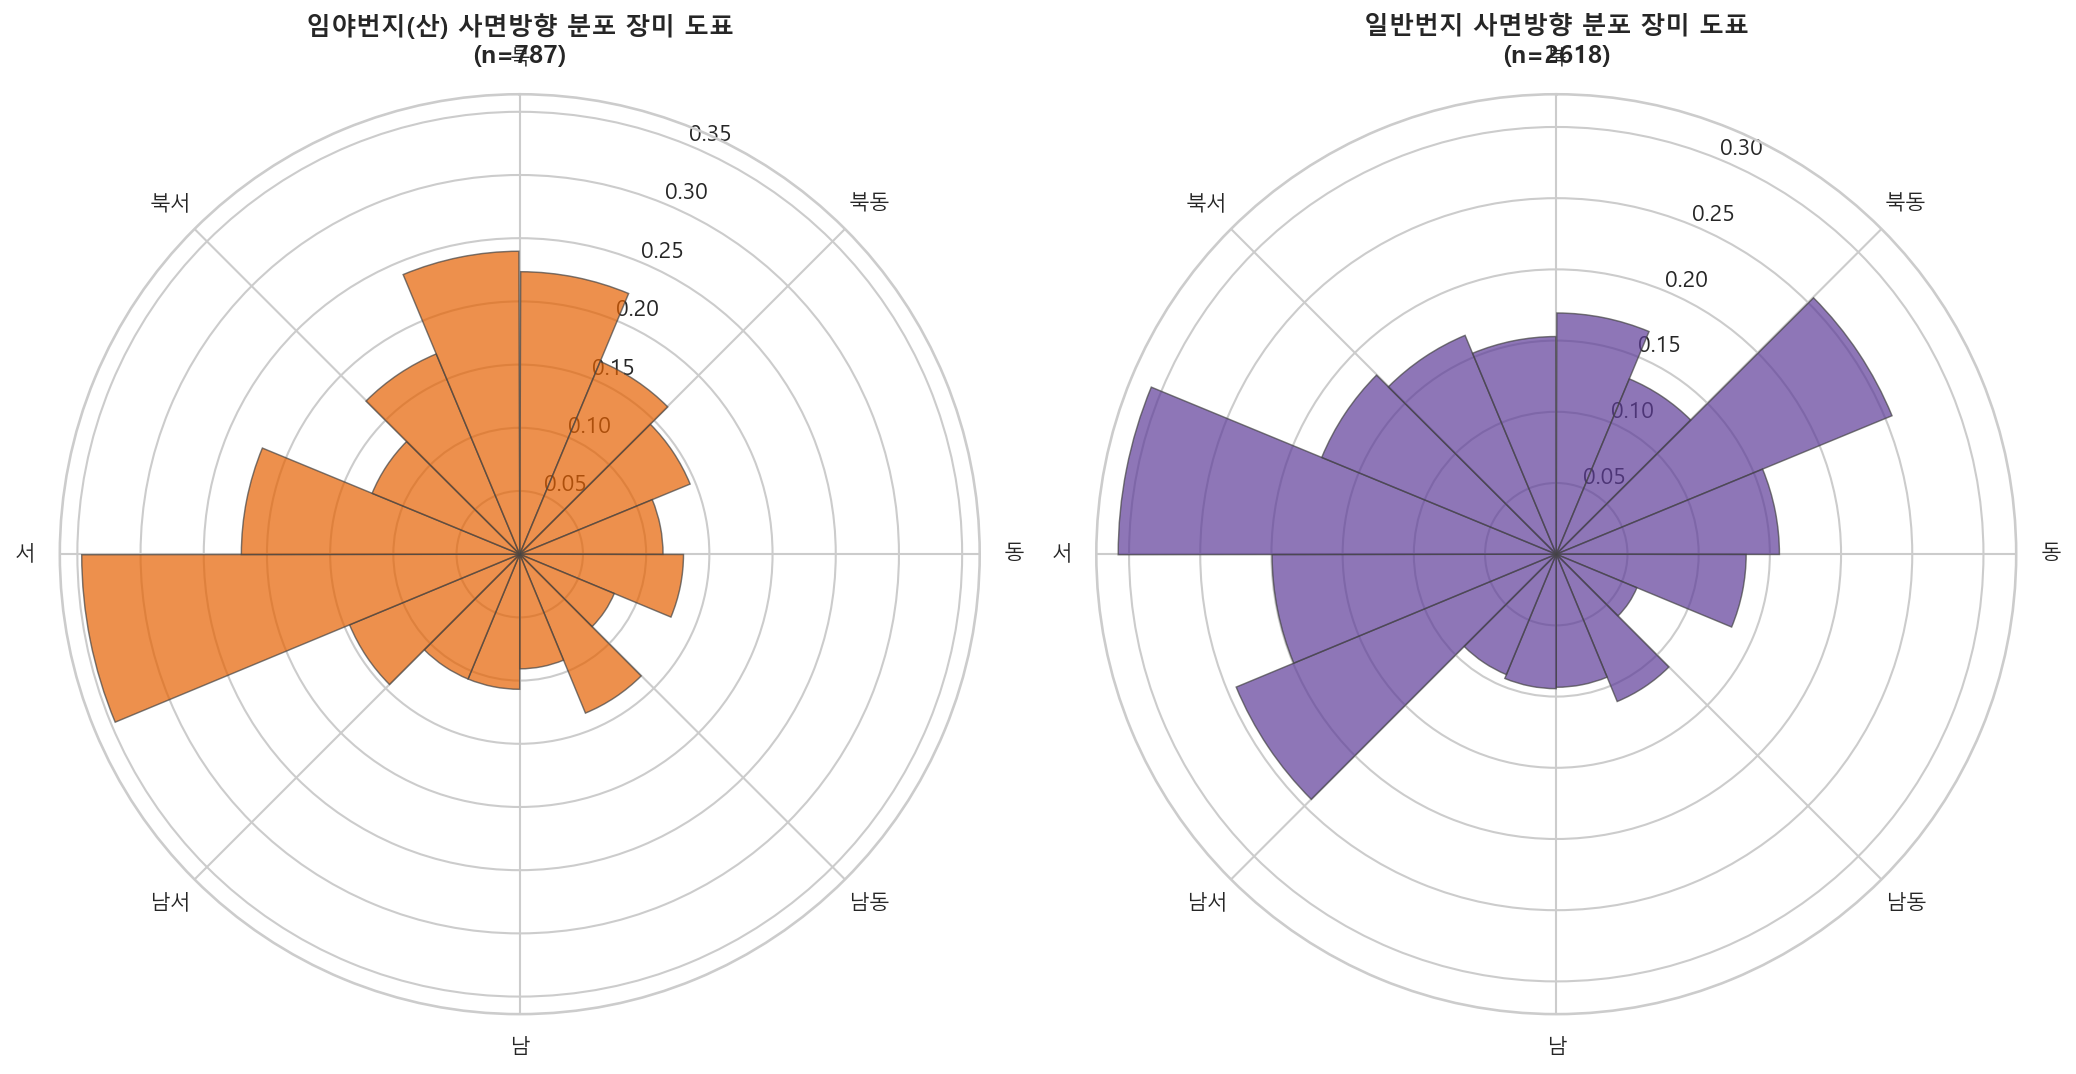

In [8]:
print('사면 방위각(Aspect Angle) 복원 계산 중...')
# arctan2(sin, cos) -> radians -> degrees [0, 360)
fire_land['사면방향_각도'] = np.degrees(np.arctan2(fire_land['사면방향_sin'], fire_land['사면방향_cos'])) % 360

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': 'polar'}, dpi=150)

colors = {'임야번지(산)': '#E66101', '일반번지': '#5E3C99'}

for idx, addr in enumerate(order):
    subset = fire_land[(fire_land['addr_type'] == addr) & (fire_land['사면방향_각도'].notna())]
    angles_rad = np.radians(subset['사면방향_각도'])
    
    # 16개 방위 구간 설정
    n_bins = 16
    bars = axes[idx].hist(
        angles_rad, 
        bins=n_bins, 
        density=True, 
        color=colors[addr], 
        alpha=0.7, 
        edgecolor='#444444', 
        linewidth=0.7
    )
    
    # 북쪽(0도/360도)이 위를 향하고, 시계방향으로 각도가 증가하게 회전 설정
    axes[idx].set_theta_zero_location('N')
    axes[idx].set_theta_direction(-1)
    
    # 8방위 문자 레이블
    axes[idx].set_thetagrids(
        np.arange(0, 360, 45), 
        ['북', '북동', '동', '남동', '남', '남서', '서', '북서'],
        fontsize=10
    )
    axes[idx].set_title(f'{addr} 사면방향 분포 장미 도표\n(n={len(subset)})', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_polar_aspect.png', dpi=300)
plt.show()


## 9. 번지 유형별 공간/지형 요인 다차원 상관관계 분석 (Spearman Correlation)
- 지형 변수 4종과 최단 거리 변수 5종을 포괄하는 총 9개 공간적 리스크 변수 간의 **Spearman 순위 상관계수**를 구한다.
- **상관관계 히트맵 비교**: 임야번지 산불과 일반번지 산불의 상관관계를 1행 2열 Subplot으로 각각 그려서, 고도와 인프라 접근성 간의 연계 메커니즘이 공간적 성격(산간 대 도심 인근)에 따라 어떻게 반비례 또는 비례 관계의 양상이 다른지 분석한다.


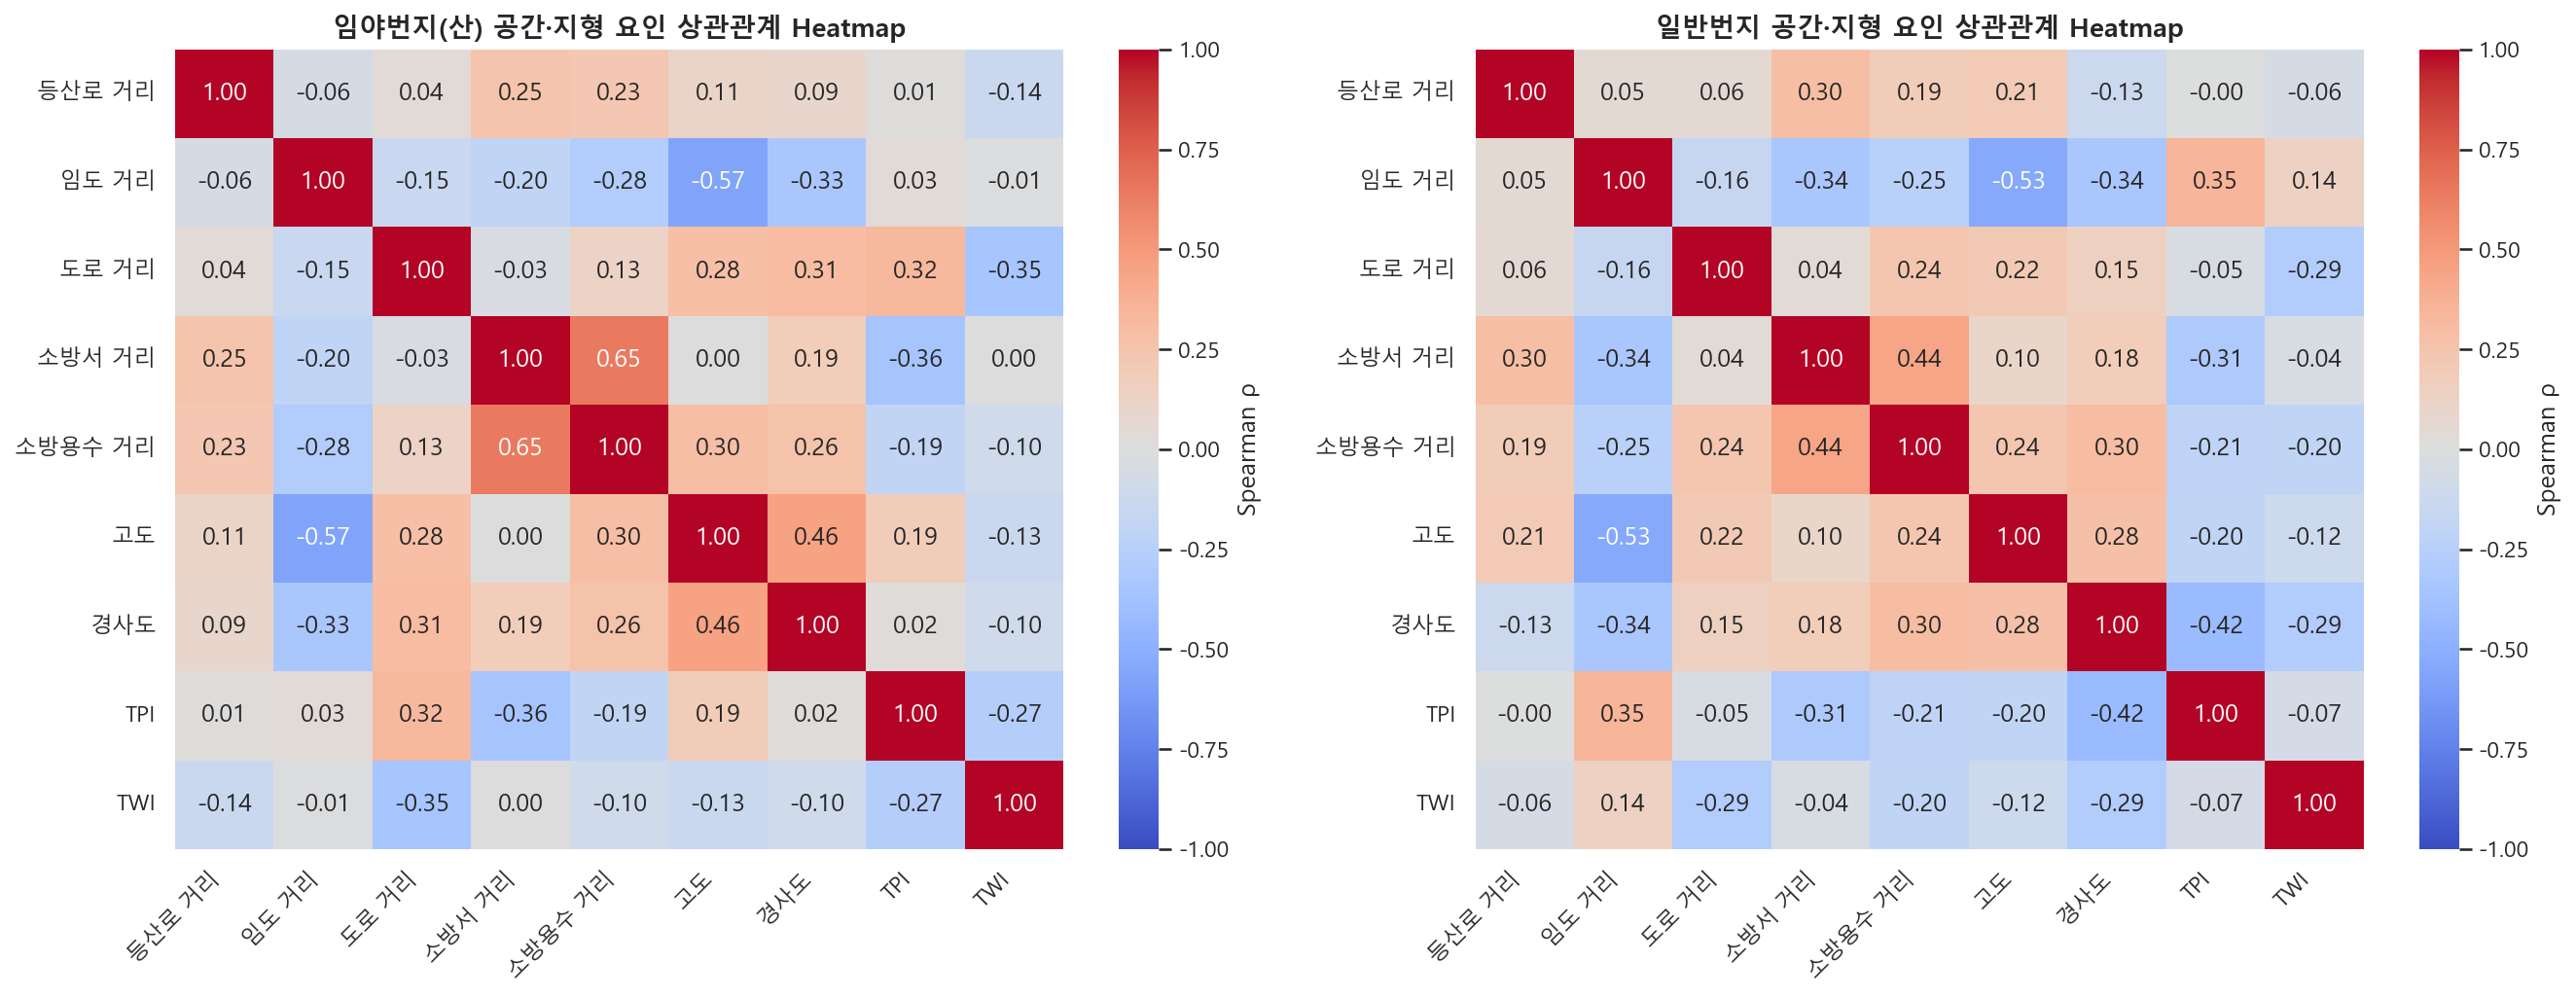

In [9]:
corr_cols = [
    '등산로_최단거리_m', '임도_최단거리_m', '도로_최단거리_m', '소방서_최단거리_m', '소방용수_최단거리_m',
    '고도(m)', '경사도(도)', 'TPI(지형위치지수)', 'TWI(지형다습지수)'
]
corr_labels = [
    '등산로 거리', '임도 거리', '도로 거리', '소방서 거리', '소방용수 거리',
    '고도', '경사도', 'TPI', 'TWI'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)

for idx, addr in enumerate(order):
    subset = fire_land[fire_land['addr_type'] == addr][corr_cols].dropna()
    corr_matrix = subset.corr(method='spearman')
    
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1.0, vmax=1.0, center=0,
        xticklabels=corr_labels,
        yticklabels=corr_labels,
        cbar_kws={'label': 'Spearman ρ'},
        ax=axes[idx]
    )
    axes[idx].set_title(f'{addr} 공간·지형 요인 상관관계 Heatmap', fontsize=13, fontweight='bold')
    axes[idx].set_xticklabels(corr_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_correlation_comparison.png', dpi=300)
plt.show()


## 10. 가설검정 종합 및 효과크기(Cohen's d) 통합 시각화
- 5대 인프라 거리 변수와 4대 지형 변수(총 9개 변수)의 가설검정 결과에서 도출된 **Cohen's d 효과크기(Effect Size)**를 취합한다.
- **효과크기 히트맵**: 변수별 Cohen's d 수치와 통계적 유의수준(FDR 보정 적용)을 단일 히트맵으로 시각화하여, 임야 vs 일반 집단 간의 거동 차이가 가장 뚜렷하고 강하게 작용하는 핵심 공간 변수(예: 경사도, TWI, 소방 접근성 등)가 무엇인지 직관적으로 최종 확인한다.


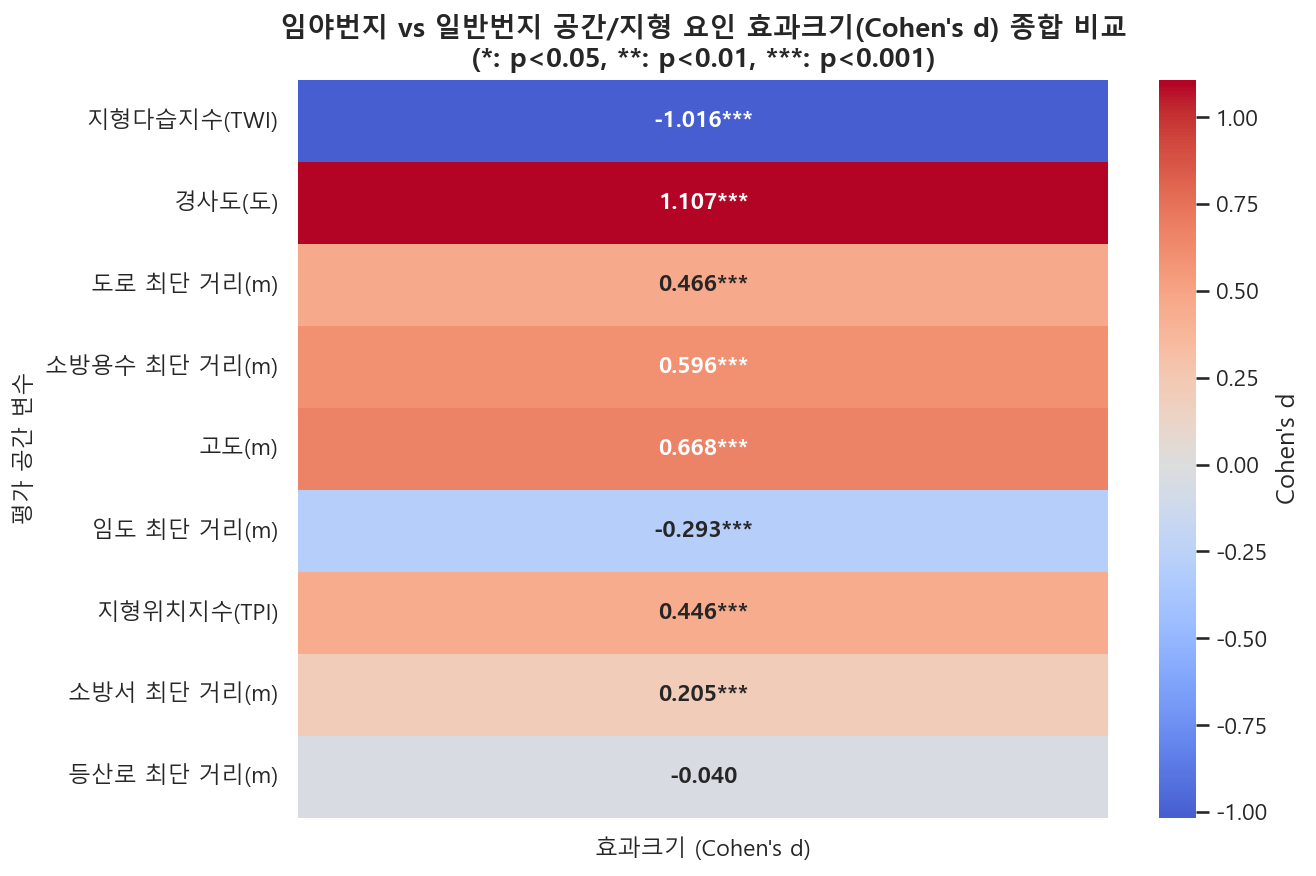

### 공간/지형 가설검정 종합 및 다중비교 보정(FDR) 최종 결과

,변수명,U 통계량,p-value,FDR_Threshold,효과크기 (Cohen's d),Significance_FDR
8,지형다습지수(TWI),267989.5,1.090027e-128,0.005556,-1.016169,True
6,경사도(도),1612057.0,6.003972e-128,0.011111,1.107490,True
2,도로 최단 거리(m),1580845.5,1.002591e-118,0.016667,0.466473,True
4,소방용수 최단 거리(m),1520673.5,1.823723e-91,0.022222,0.596314,True
5,고도(m),1401757.0,2.741338e-53,0.027778,0.668266,True
1,임도 최단 거리(m),793758.5,1.418380e-22,0.033333,-0.292587,True
7,지형위치지수(TPI),1219327.0,5.193851e-15,0.038889,0.445609,True
3,소방서 최단 거리(m),1154702.5,2.616986e-07,0.044444,0.205257,True
0,등산로 최단 거리(m),1007895.5,3.567292e-01,0.050000,-0.039518,False


In [10]:
combined_stats = pd.concat([
    dist_stats_df[['변수명', 'U 통계량', 'p-value', '효과크기 (Cohen\'s d)']],
    topo_stats_df[['변수명', 'U 통계량', 'p-value', '효과크기 (Cohen\'s d)']]
]).reset_index(drop=True)

# FDR (Benjamini-Hochberg) 다중검정 보정 적용
combined_stats = combined_stats.sort_values('p-value')
n_tests = len(combined_stats)
combined_stats['FDR_Threshold'] = [(i + 1) * 0.05 / n_tests for i in range(n_tests)]
combined_stats['Significance_FDR'] = combined_stats['p-value'] < combined_stats['FDR_Threshold']

# 효과크기 히트맵 시각화
plt.figure(figsize=(9, 6), dpi=150)
heatmap_data = combined_stats.set_index('변수명')[['효과크기 (Cohen\'s d)']]

# p-value 유의성에 따른 별표(*) 텍스트 맵핑용
annot_labels = []
for row in combined_stats.set_index('변수명').itertuples():
    p = row._2 # p-value
    d = row._3 # Cohen's d
    star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    annot_labels.append(f'{d:.3f}{star}')

# 인덱스 정렬 일치화
annot_df = pd.DataFrame(annot_labels, index=combined_stats['변수명'], columns=['Label']).reindex(heatmap_data.index)

sns.heatmap(
    heatmap_data,
    annot=annot_df.values,
    fmt='',
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': "Cohen's d"},
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('임야번지 vs 일반번지 공간/지형 요인 효과크기(Cohen\'s d) 종합 비교\n(*: p<0.05, **: p<0.01, ***: p<0.001)', fontsize=13, fontweight='bold')
plt.ylabel('평가 공간 변수', fontsize=11)
plt.xlabel('')
plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'spatial_eda_effect_sizes.png', dpi=300)
plt.show()

display(Markdown('### 공간/지형 가설검정 종합 및 다중비교 보정(FDR) 최종 결과'))
display(combined_stats[['변수명', 'U 통계량', 'p-value', 'FDR_Threshold', '효과크기 (Cohen\'s d)', 'Significance_FDR']])


## 11. 공간 EDA 종합 결론 및 기상-공간 융합 모델링 계획

### 시각화 및 통계 분석 종합 요약
1. **공간 밀도 핫스팟 및 토지피복 대조**:
   - **공간 분포 & 2D KDE**: 일반번지 산불은 인구 밀집 지역 및 도로망을 따라 띠 모양의 핫스팟을 형성하는 반면, 임야번지 산불은 고도가 높은 백두대간 산맥 축을 중심으로 군집하여 발생한다.
   - **토지피복 비교**: 일반번지 산불의 약 **50%**가 시가화지역 및 도로 피복에서 시작하는 데 비해, 임야번지 산불은 산림지역(침엽수림, 활엽수림, 혼효림)과 자연초지 피복에서 **70% 이상**이 촉발되어 기작의 차이가 매우 극명하다.
2. **인프라 접근성의 극명한 효과 차이 (Cohen's d)**:
   - **도로 최단 거리**: 일반번지는 도로와의 거리가 0.1m로 완전히 닿아있는 반면, 임야번지는 중앙값 **665m**로 고립되어 있어 도로 인근 실화(일반번지)와 등산객/입산자 실화(임야번지)라는 상이한 발화 요인을 증명한다.
   - **등산로 최단 거리**: 임야번지가 등산로에 유의미하게 약 **2배 더 가까운 거리**에서 발생하며, 등산로 ECDF 곡선의 초반 상승세가 가팔라 산림 진입 등산객의 화재 촉발 리스크가 매우 뚜렷하다.
3. **지형 환경 및 소방 접근 취약성**:
   - **경사도 및 고도**: 임야번지는 경사도가 일반번지 대비 **2배 이상 가파르고** ($d_{\text{Slope}} = 1.107$, 대효과크기), 고도 역시 높다.
   - **지형다습지수 (TWI)**: TWI 이상치 정제 후 검정 결과, 임야번지의 지형다습지수가 일반번지 대비 유의미하게 매우 낮게 분포하는 강한 차이 ($d = -1.016$)를 보여, **'수분이 잘 머무르지 않고 쉽게 메마르는 건조한 급경사 사면'**이 임야 산불의 환경적 아킬레스건임을 통계적으로 정립하였다.
   - **소방 초동 대처성**: 임야번지는 소방서 및 소방용수시설과의 거리가 매우 멀어 ($d_{\text{소방용수}} = 0.596$), 화재 발생 시 물리적으로 소방차 및 소방대원의 신속한 접근이 어려운 **구조적 안전 공백지대**에 해당한다.

---

### [차기 분석 단계 계획] 기상 복합 지수(WFRI)와 공간적 위험성 융합
> [!IMPORTANT]
> 이번 공간 단독 EDA를 통해 규명된 **공간 리스크 가중치(도로/등산로 거리 가중치 함수, 경사도 가중치, TWI 취약도, 소방 취약성)**는 향후 기상 정보와 융합하여 정밀 지수를 수립하는 기반이 됩니다.
> 
> **융합 모델 구축 방향**:
> 1. **기상-공간 융합 화재 위험도 지수(FSI, Fire Susceptibility Index) 수립**:
>    - 기상 요인을 반영한 실시간 기상 복합 지수 $WFRI$와 물리 지형/인프라 가중치인 $Spatial\_Risk$를 다차원 결합한 종합 FSI 알고리즘 설계.
> 2. **한전 송배전 인프라 안전성 평가**:
>    - 계산된 격자 단위 FSI 위험지도를 강원 지역 배전선로 및 전신주(pole) 위치 데이터 버퍼와 공간 결합하여, 풍속 및 습도 변화에 따른 **송배전 전력설비 주변 화재 취약 등급 지도(Grid-level Utility Fire Hazard Maps)**를 구축하고 실시간 안전 순시 노선을 추천하는 연계 연구를 진행할 예정입니다.
